In [2]:
import os

image_folder = "../data/val2017"

total_images = len(os.listdir(image_folder))
print("Total Images:", total_images)


Total Images: 5000


loading annotations into memory...
Done (t=0.65s)
creating index...
index created!
Selected Images: ['000000108244.jpg', '000000383621.jpg', '000000016451.jpg', '000000359135.jpg', '000000456865.jpg']


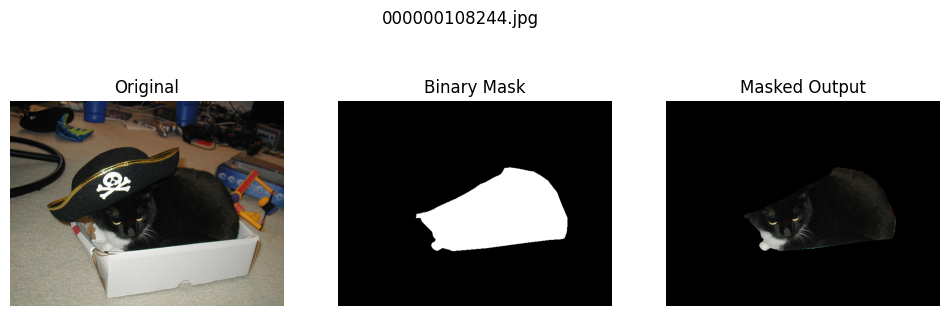

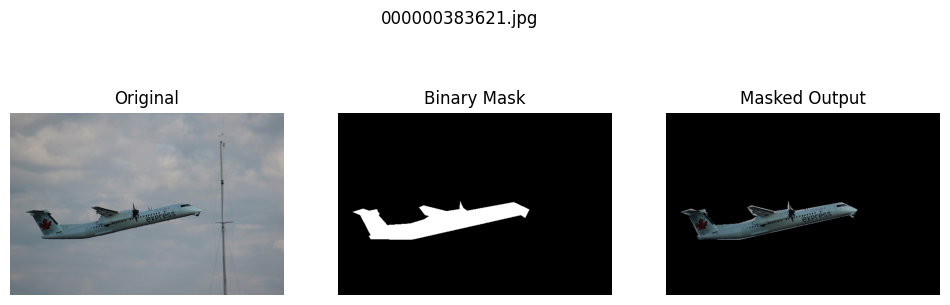

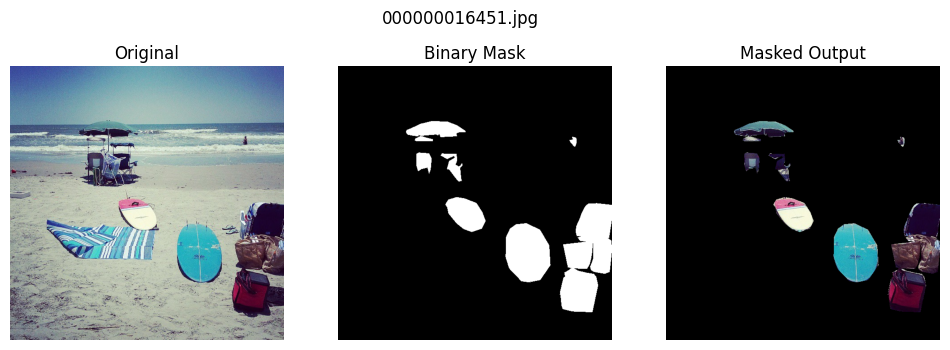

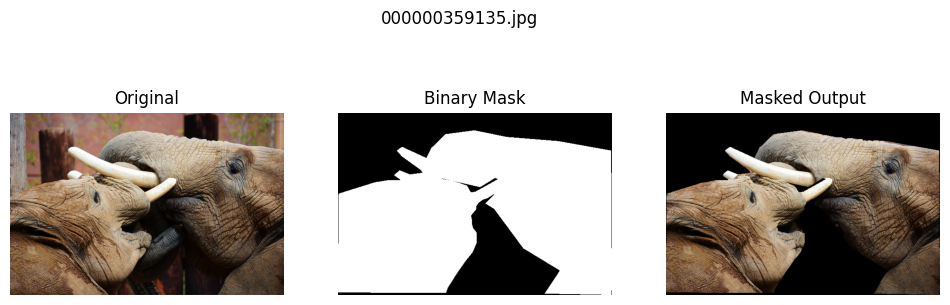

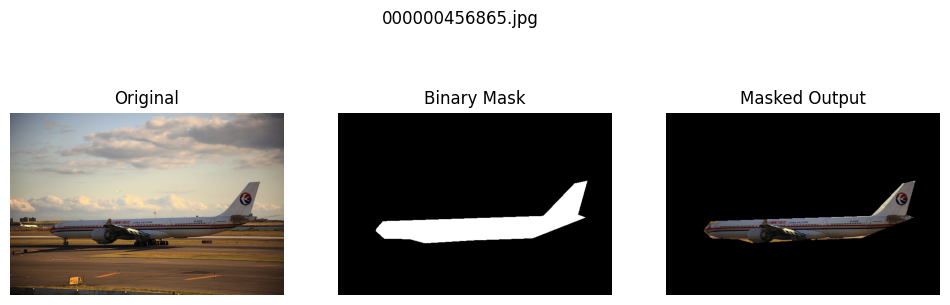

Done!


In [3]:
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pycocotools.coco import COCO

# Paths
annotation_path = "../data/annotations/instances_val2017.json"
#train_dir = "../data/processed/train"
train_dir = "../data/val2017"
output_dir = "../data/processed/sample_binary_masks"

os.makedirs(output_dir, exist_ok=True)

# Load COCO
coco = COCO(annotation_path)

# Get image info once (optimization)
img_ids = coco.getImgIds()
img_infos = coco.loadImgs(img_ids)

# Get train images
train_images = os.listdir(train_dir)

# Select 5 random images
selected_images = random.sample(train_images, 5)

print("Selected Images:", selected_images)

for img_name in selected_images:

    # Find image info in JSON
    img_info = None
    for info in img_infos:
        if info["file_name"] == img_name:
            img_info = info
            break

    if img_info is None:
        print(f"Skipping {img_name}")
        continue

    img_id = img_info["id"]
    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)

    # Create binary mask
    mask = np.zeros((img_info["height"], img_info["width"]), dtype=np.uint8)

    for ann in anns:
        mask = np.maximum(mask, coco.annToMask(ann))

    mask = mask * 255

    # Save mask
    mask_path = os.path.join(output_dir, img_name.replace(".jpg", ".png"))
    cv2.imwrite(mask_path, mask)

    # Load original image
    img_path = os.path.join(train_dir, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Apply mask
    masked_img = cv2.bitwise_and(img, img, mask=mask)

    # Display for THIS image
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(mask, cmap="gray")
    plt.title("Binary Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(masked_img)
    plt.title("Masked Output")
    plt.axis("off")

    plt.suptitle(img_name)
    plt.show()

print("Done!")


In [4]:
import os
import cv2
import numpy as np
from pycocotools.coco import COCO
from tqdm.notebook import tqdm

# ================= PATH SETTINGS =================
BASE_PATH = "../data"   # Because notebook is inside notebooks/
ANNOTATION_FILE = os.path.join(BASE_PATH, "annotations/instances_val2017.json")
PROCESSED_FOLDER = os.path.join(BASE_PATH, "processed")
IMG_SIZE = 256
# =================================================

coco = COCO(ANNOTATION_FILE)


def create_binary_mask(img_id, height, width):
    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)

    mask = np.zeros((height, width), dtype=np.uint8)

    for ann in anns:
        mask = np.maximum(mask, coco.annToMask(ann))

    return np.where(mask > 0, 255, 0).astype("uint8")


def preprocess_image(img, mask, split_type, img_name):

    save_base = os.path.join(PROCESSED_FOLDER, split_type)
    os.makedirs(save_base, exist_ok=True)

    # Resize
    resized_img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    resized_mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE),
                              interpolation=cv2.INTER_NEAREST)

    # Normalize
    normalized_img = resized_img / 255.0

    # Save processed outputs
    cv2.imwrite(os.path.join(save_base, img_name + "_resized.jpg"),
                cv2.cvtColor(resized_img, cv2.COLOR_RGB2BGR))

    cv2.imwrite(os.path.join(save_base, img_name + "_normalized.jpg"),
                (normalized_img * 255).astype(np.uint8))

    cv2.imwrite(os.path.join(save_base, img_name + "_mask.png"),
                resized_mask)

    # Subject isolation
    isolated = cv2.bitwise_and(resized_img, resized_img, mask=resized_mask)
    cv2.imwrite(os.path.join(save_base, img_name + "_isolated.jpg"),
                cv2.cvtColor(isolated, cv2.COLOR_RGB2BGR))

    # TRAIN AUGMENTATIONS ONLY
    if split_type == "train":

        h_flip = cv2.flip(resized_img, 1)
        cv2.imwrite(os.path.join(save_base, img_name + "_hflip.jpg"),
                    cv2.cvtColor(h_flip, cv2.COLOR_RGB2BGR))

        v_flip = cv2.flip(resized_img, 0)
        cv2.imwrite(os.path.join(save_base, img_name + "_vflip.jpg"),
                    cv2.cvtColor(v_flip, cv2.COLOR_RGB2BGR))

        center = (IMG_SIZE // 2, IMG_SIZE // 2)
        rot_matrix = cv2.getRotationMatrix2D(center, 30, 1.0)
        rotated = cv2.warpAffine(resized_img, rot_matrix,
                                 (IMG_SIZE, IMG_SIZE))
        cv2.imwrite(os.path.join(save_base, img_name + "_rot30.jpg"),
                    cv2.cvtColor(rotated, cv2.COLOR_RGB2BGR))

        bright = np.clip(normalized_img * 1.5, 0, 1)
        cv2.imwrite(os.path.join(save_base, img_name + "_bright.jpg"),
                    (bright * 255).astype(np.uint8))


def process_split(split_type):

    split_folder = os.path.join(PROCESSED_FOLDER, split_type)

    if not os.path.exists(split_folder):
        print(f"{split_type} folder not found!")
        return

    print(f"\nProcessing {split_type} images...")

    # ✅ Only process original images (avoid reprocessing)
    image_files = [
        f for f in os.listdir(split_folder)
        if f.endswith(".jpg") and
        "_resized" not in f and
        "_normalized" not in f and
        "_isolated" not in f and
        "_hflip" not in f and
        "_vflip" not in f and
        "_rot30" not in f and
        "_bright" not in f
    ]

    for file_name in tqdm(image_files):

        img_path = os.path.join(split_folder, file_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img_id = int(file_name.split(".")[0])

        img_info = coco.loadImgs(img_id)[0]
        height, width = img_info["height"], img_info["width"]

        mask = create_binary_mask(img_id, height, width)

        preprocess_image(img, mask, split_type, file_name.split(".")[0])


# ================= RUN =================

process_split("train")
process_split("val")
process_split("test")

print("\nPreprocessing Completed Successfully!")


loading annotations into memory...
Done (t=0.71s)
creating index...
index created!

Processing train images...


  0%|          | 0/3500 [00:00<?, ?it/s]


Processing val images...


  0%|          | 0/750 [00:00<?, ?it/s]


Processing test images...


  0%|          | 0/750 [00:00<?, ?it/s]


Preprocessing Completed Successfully!


Train Path: c:\Users\Mula Sriya\OneDrive\Desktop\VISIONEXTRACT\data\processed\train
Original Path: c:\Users\Mula Sriya\OneDrive\Desktop\VISIONEXTRACT\data\val2017
Total unique image IDs found: 3500

Showing outputs for Image ID: 000000511999


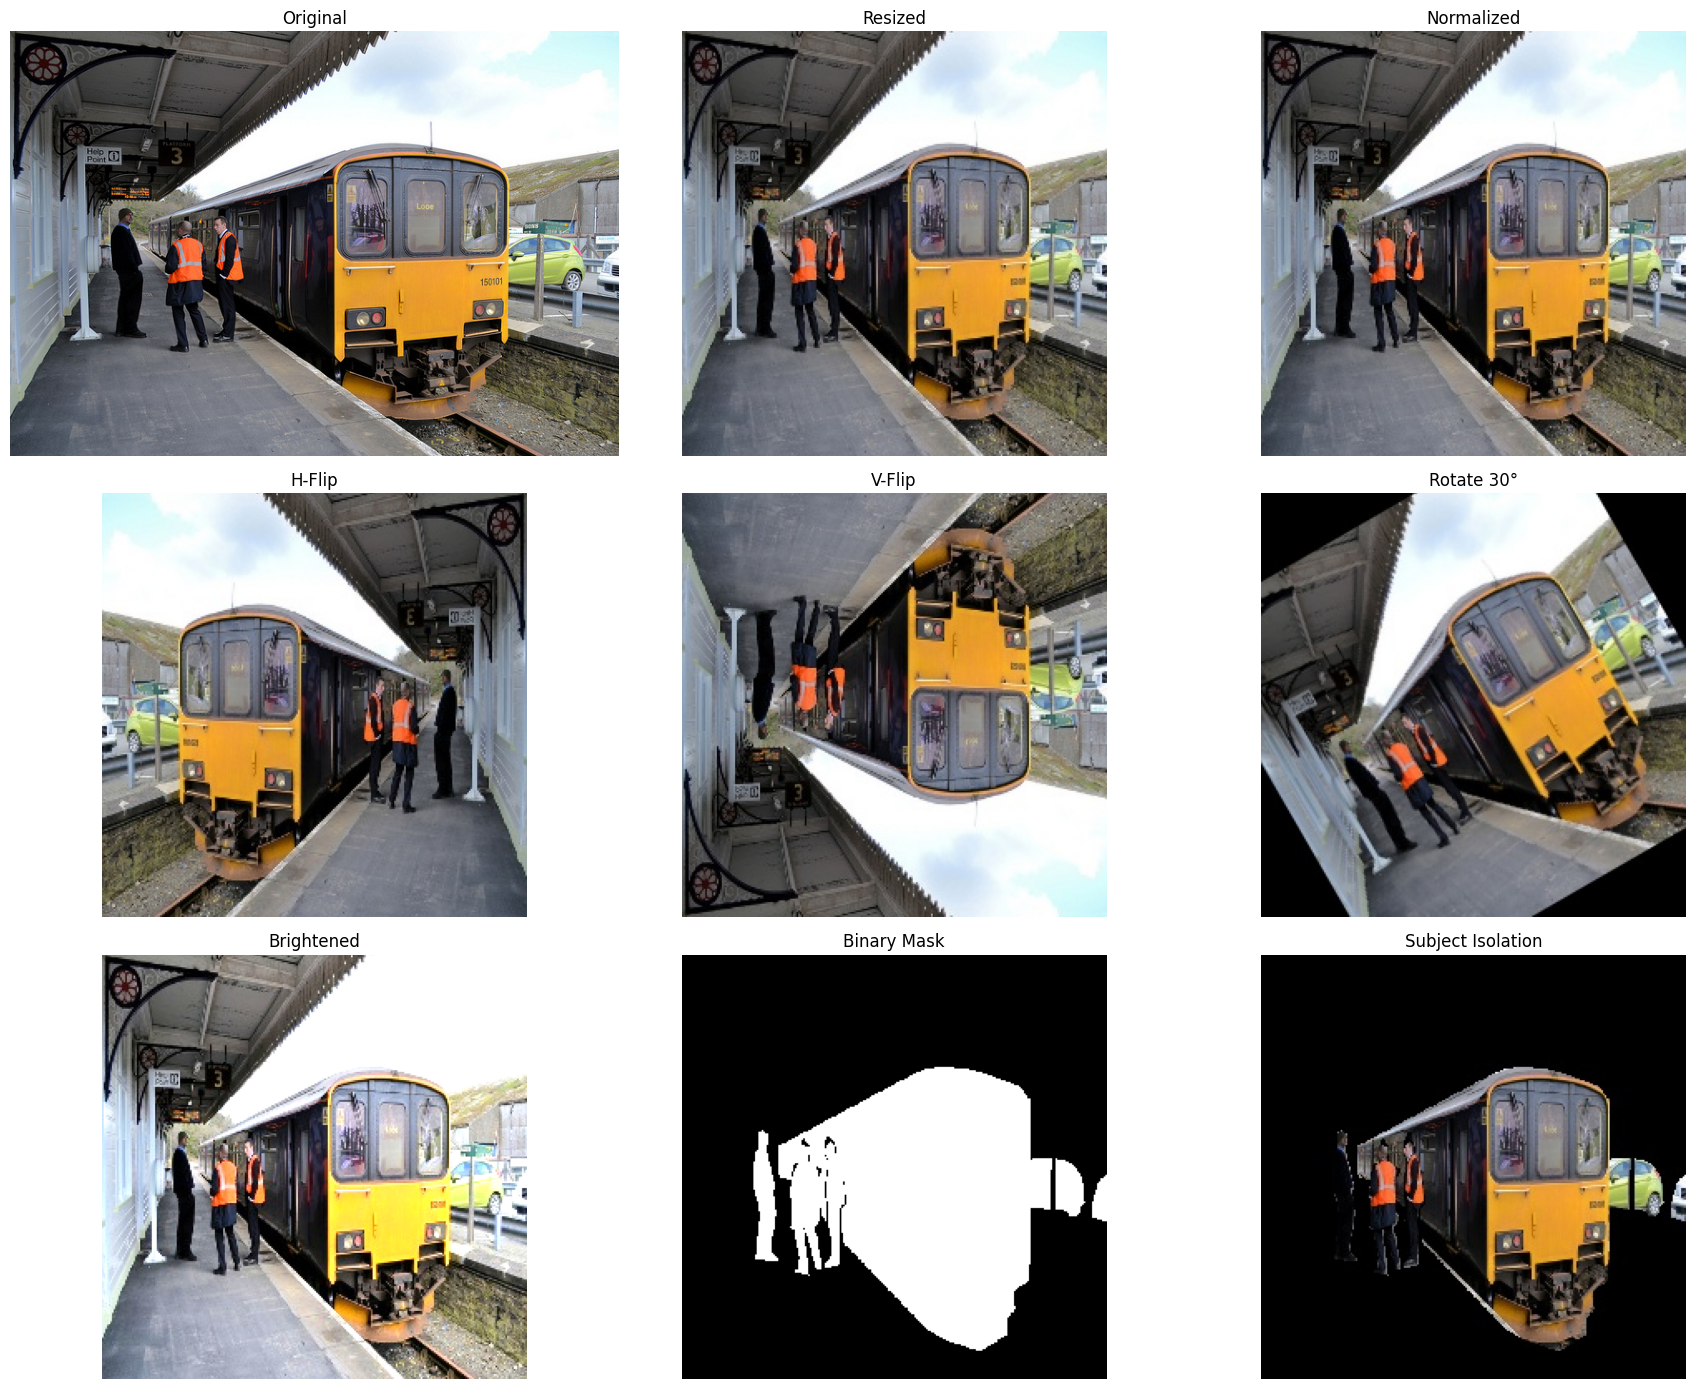


Showing outputs for Image ID: 000000221213


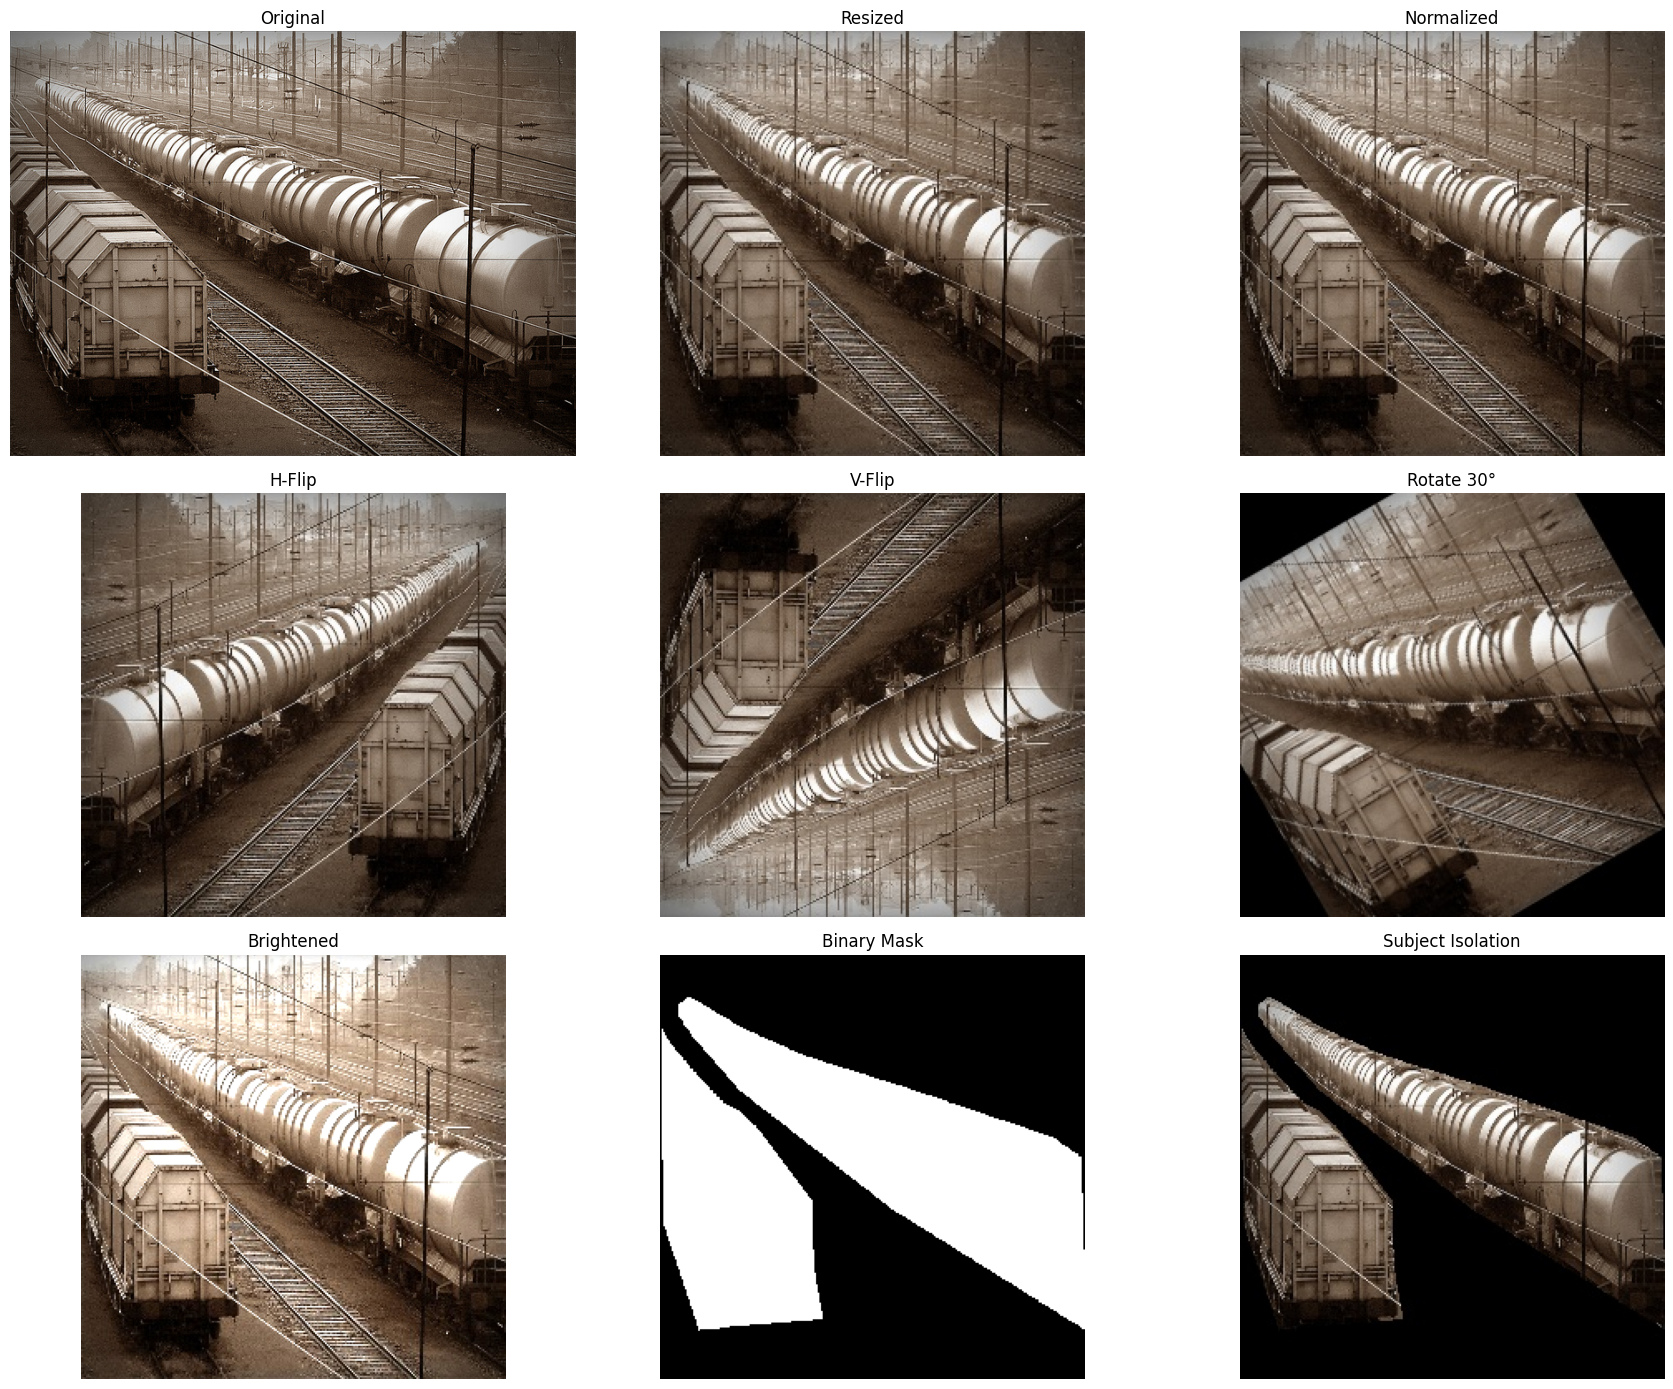


Showing outputs for Image ID: 000000017207


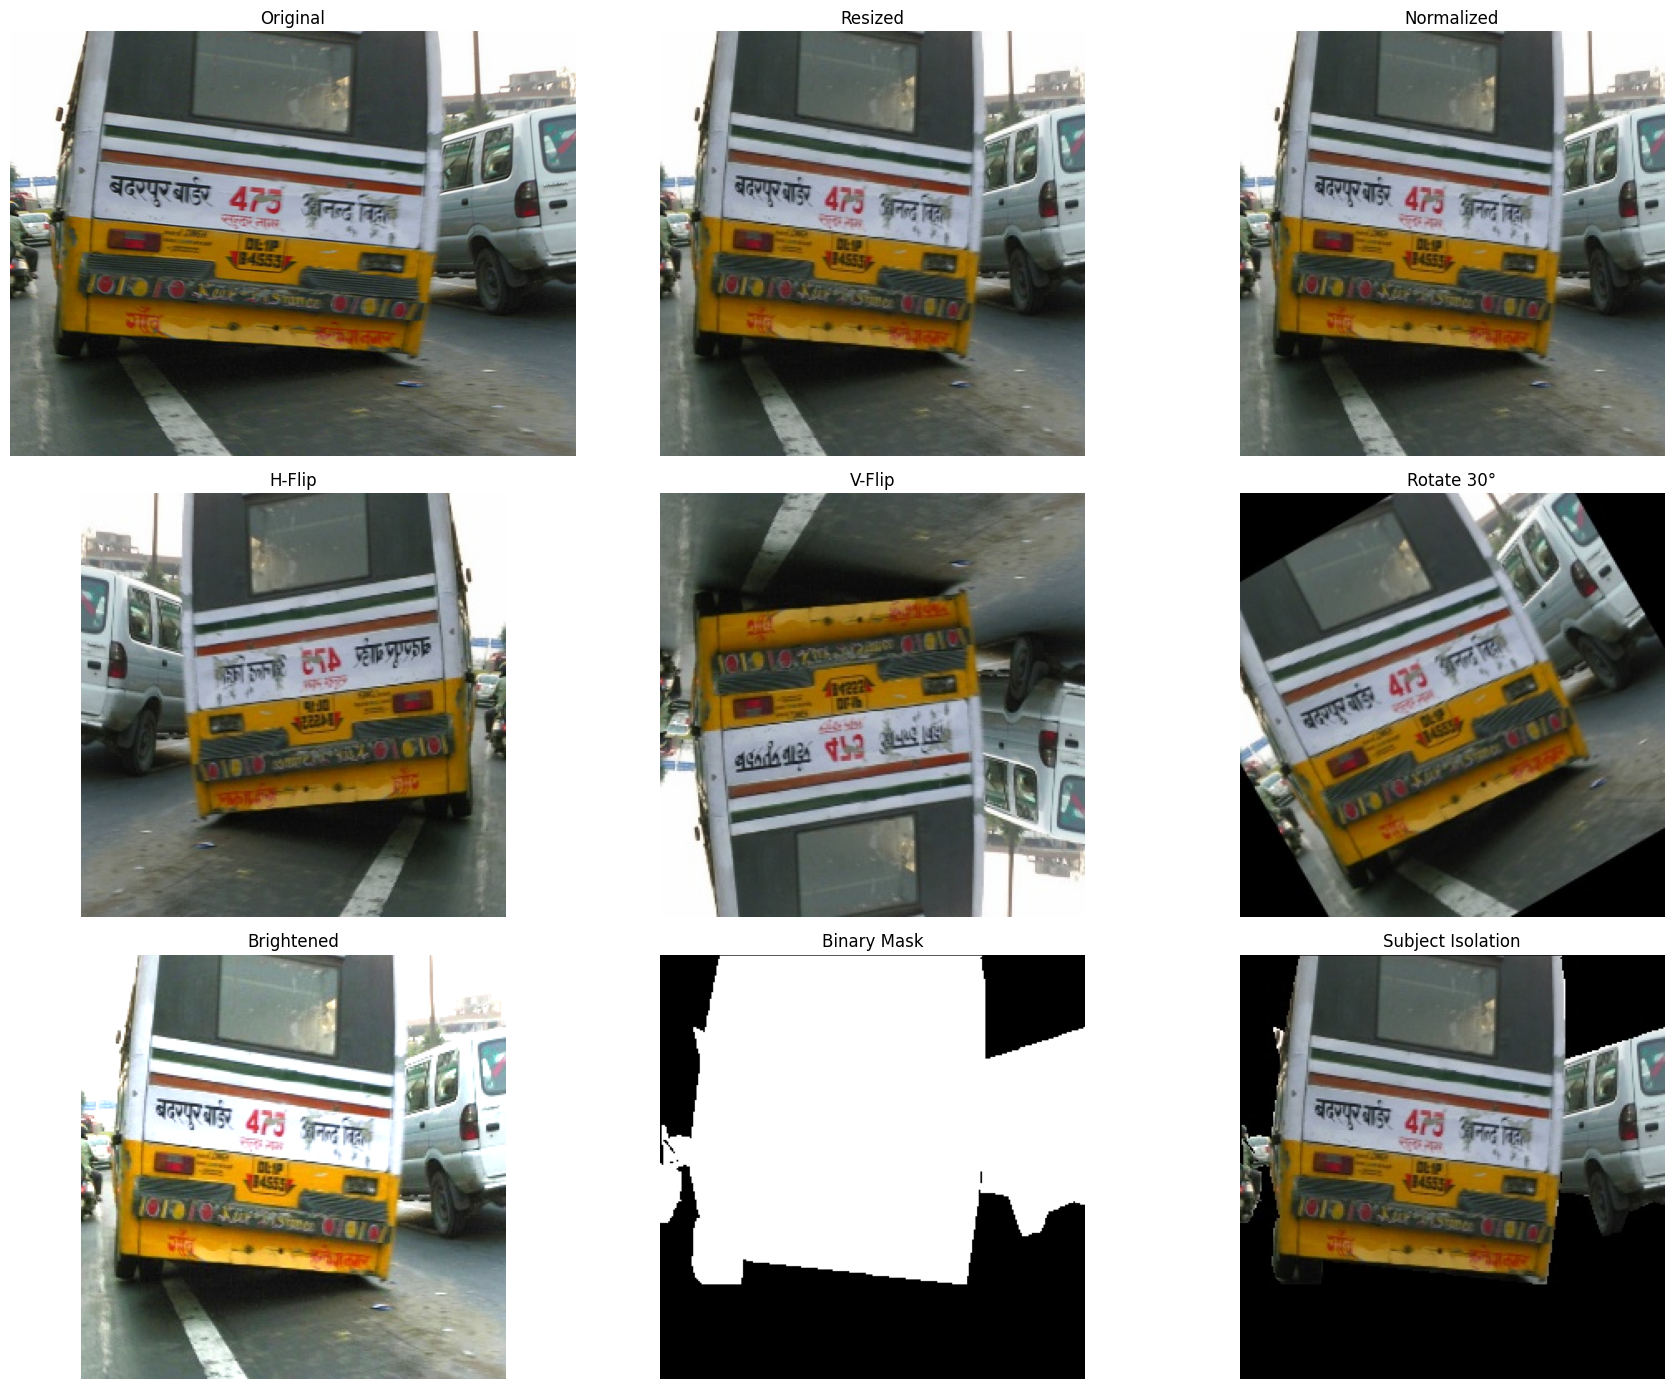

In [5]:
import os
import cv2
import matplotlib.pyplot as plt
import random
import numpy as np

# ================= PATH SETUP =================

CURRENT_DIR = os.getcwd()
BASE_PATH = os.path.abspath(os.path.join(CURRENT_DIR, "..", "data"))

TRAIN_PATH = os.path.join(BASE_PATH, "processed", "train")
ORIGINAL_PATH = os.path.join(BASE_PATH, "val2017")  # original COCO images folder

print("Train Path:", TRAIN_PATH)
print("Original Path:", ORIGINAL_PATH)

# =============================================

files = os.listdir(TRAIN_PATH)

# Extract clean IDs
image_ids = list(set([f.split("_")[0].split(".")[0] for f in files]))

print("Total unique image IDs found:", len(image_ids))

sample_ids = random.sample(image_ids, 3)

for img_id in sample_ids:

    print(f"\nShowing outputs for Image ID: {img_id}")

    def safe_read(path, gray=False):
        if os.path.exists(path):
            return cv2.imread(path, 0 if gray else 1)
        else:
            return None

    # Load original image
    original = safe_read(os.path.join(ORIGINAL_PATH, f"{img_id}.jpg"))

    # Load processed images
    resized = safe_read(os.path.join(TRAIN_PATH, f"{img_id}_resized.jpg"))
    hflip = safe_read(os.path.join(TRAIN_PATH, f"{img_id}_hflip.jpg"))
    vflip = safe_read(os.path.join(TRAIN_PATH, f"{img_id}_vflip.jpg"))
    rot = safe_read(os.path.join(TRAIN_PATH, f"{img_id}_rot30.jpg"))
    mask = safe_read(os.path.join(TRAIN_PATH, f"{img_id}_mask.png"), gray=True)
    isolated = safe_read(os.path.join(TRAIN_PATH, f"{img_id}_isolated.jpg"))

    images_check = [original, resized, hflip, vflip, rot, mask, isolated]

    if any(img is None for img in images_check):
        print("Skipping incomplete image set.")
        continue

    # Convert BGR → RGB
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    resized = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
    hflip = cv2.cvtColor(hflip, cv2.COLOR_BGR2RGB)
    vflip = cv2.cvtColor(vflip, cv2.COLOR_BGR2RGB)
    rot = cv2.cvtColor(rot, cv2.COLOR_BGR2RGB)
    isolated = cv2.cvtColor(isolated, cv2.COLOR_BGR2RGB)

    # Compute normalized & bright in memory
    normalized = resized / 255.0
    bright = np.clip(normalized * 1.5, 0, 1)

    # Plot 3x3 grid
    plt.figure(figsize=(18,14))

    titles = [
        "Original",
        "Resized",
        "Normalized",
        "H-Flip",
        "V-Flip",
        "Rotate 30°",
        "Brightened",
        "Binary Mask",
        "Subject Isolation"
    ]

    display_images = [
        original,
        resized,
        normalized,
        hflip,
        vflip,
        rot,
        bright,
        mask,
        isolated
    ]

    for i in range(9):
        plt.subplot(3,3,i+1)

        if i == 7:  # mask
            plt.imshow(display_images[i], cmap="gray")
        else:
            plt.imshow(display_images[i])

        plt.title(titles[i])
        plt.axis("off")

    plt.tight_layout()
    plt.show()
